In [1]:
!pip install anndata==0.8.0

  Using cached anndata-0.8.0-py3-none-any.whl (96 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 25.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: h5py
    Found existing installation: h5py 2.10.0
    Uninstalling h5py-2.10.0:
      Successfully uninstalled h5py-2.10.0
  Attempting uninstall: anndata
    Found existing installation: anndata 0.7.8
    Uninstalling anndata-0.7.8:
      Successfully uninstalled anndata-0.7.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
samap 1.0.2 requires h5py<=2.10, but you have h5py 3.8.0 which is incompatible.
sam-algorithm 1.0.0 requires h5py<=2.10.0, but you have h5py 3.8.0 which is incompatible.


In [13]:
dlx_list = ['Slc32a1', 'Gad1', 'Gad2', 'Grik3', 'Nrxn3', 'Ecel1', 'Actr5', 'Cpne2','Gpc4', 'Eif1b']

In [14]:
nfix_list = ['Chd7','Adamtsl3','Gpd1','Cd9','Htr3a','P2rx7','Rnf141','Fdxr','Abcb8','Lama4']

In [56]:
uncx_list = ['Tmem163','Slc17a6','Cacna2d1','Nrn1','Mab21l2','Chst8','Tmem229b','F13a1','Fras1','Epb41l4a']

In [11]:
def orthogroup_mapper(orthogroups, label):
    mapping = {}
    for index in orthogroups.index:
        gene_list = orthogroups.loc[index, label]
        if type(gene_list) != float:
            genes = gene_list.split(',')
            for item in genes:
                mapping[item] = index
    return(mapping)

In [3]:
scenic = pd.read_csv('eRegulon_direct_guang.tsv', delimiter = '\t')

In [33]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)
for item in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique():
    if item[:2] == 'mo' or item[:2] == 'mg':
        parent_dict[item] = 'hypo'
        
for item in sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique():
    if item[:2] == 'cj' or item[:2] == 'mg' or item[:2] == 'ac' or item[:2] == 'xt' or item[:2] == 'dr':
        parent_dict[item] = 'hypo'
        
for item in sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique():
    if item[:2] == 'cj' or item[:2] == 'mg' or item[:2] == 'ac' or item[:2] == 'xt' or item[:2] == 'dr':
        parent_dict[item] = 'hypo'
        
for item in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique():
    if item[:2] == 'cj' or item[:2] == 'mg' or item[:2] == 'ac' or item[:2] == 'xt' or item[:2] == 'dr':
        parent_dict[item] = 'hypo'
        
for item in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique():
    if item[:2] == 'cj' or item[:2] == 'mg' or item[:2] == 'ac' or item[:2] == 'xt' or item[:2] == 'dr':
        parent_dict[item] = 'hypo'

In [34]:
parent_dict['hypo'] = 'hypo'
parent_dict['not hypo'] = 'not hypo'

In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from sklearn.neighbors import KernelDensity
import time
import dill
import pickle
from scipy.spatial import distance
import os
import scipy
from tqdm import tqdm

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
sam_mg = SAM()
sam_mg.load_data('Active_SAM_joined/SAM_Allen_Institute_allhypo_01272026.h5ad')
gene_dict_mg = {}
for i in range(len(sam_mg.adata.var_names)):
    gene_dict_mg[sam_mg.adata.var_names[i]] = i

In [5]:
sam_mo = SAM()
sam_mo.load_data('Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_NN_04142026.h5ad')
gene_dict_mo = {}
for i in range(len(sam_mo.adata.var_names)):
    gene_dict_mo[sam_mo.adata.var_names[i]] = i

In [6]:
sam_cj = SAM()
sam_cj.load_data('Active_SAM_joined/SAM_CJ_joined_v2_cleaned_geneexp_NN_06192025.h5ad')
gene_dict_cj = {}
for i in range(len(sam_cj.adata.var_names)):
    gene_dict_cj[sam_cj.adata.var_names[i]] = i

In [7]:
sam_ac= SAM()
sam_ac.load_data('Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_NN_geneexp_06192025.h5ad')
gene_dict_ac = {}
for i in range(len(sam_ac.adata.var_names)):
    gene_dict_ac[sam_ac.adata.var_names[i]] = i

In [8]:
sam_xt = SAM()
sam_xt.load_data('Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_NN_geneexp_06192025.h5ad')
gene_dict_xt = {}
for i in range(len(sam_xt.adata.var_names)):
    gene_dict_xt[sam_xt.adata.var_names[i]] = i

In [9]:
sam_dr = SAM()
sam_dr.load_data('Active_SAM_joined/SAM_DR_ncbi_NN_geneexp_11202025.h5ad')
gene_dict_dr = {}
for i in range(len(sam_dr.adata.var_names)):
    gene_dict_dr[sam_dr.adata.var_names[i]] = i

In [10]:
TF = pd.read_csv('Fin_TF_06012026.csv')
TF_set = set(TF['0'])

In [12]:
otohomo = pd.read_csv('OTO_star_nothreshold_6species_ohnlogs_expressionthresh_07062026.tsv',delimiter = '\t', index_col = 'MM')

In [13]:
orthogroups = pd.read_csv('Vert_emapper_allorgs_07032026.tsv', delimiter = '\t',index_col = 'Unnamed: 0')
mm_mapping_ortho = orthogroup_mapper(orthogroups, 'MM')
mo_mapping_ortho = orthogroup_mapper(orthogroups, 'MO')
cj_mapping_ortho = orthogroup_mapper(orthogroups, 'CJ')
ac_mapping_ortho = orthogroup_mapper(orthogroups, 'AC')
xt_mapping_ortho = orthogroup_mapper(orthogroups, 'XT')
dr_mapping_ortho = orthogroup_mapper(orthogroups,'DR')

In [14]:
overall_TF_set = set(otohomo.index) & TF_set

In [92]:
test_genes = ['Dlx2','Isl1']

In [93]:
a = 0
for item in test_genes:
    if item in overall_TF_set:
        a += 1

In [94]:
a

2

In [95]:
exp = sam_mg.adata.X.A
all_exp_ct = np.zeros((sam_mg.adata.obs['subclass_id_label'].nunique(),len(sam_mg.adata.var_names)))
ctl = sam_mg.adata.obs['subclass_id_label'].unique()
for i in range(len(ctl)):
    all_exp_ct[i,:] = np.average(exp[sam_mg.adata.obs['subclass_id_label'] == ctl[i],:], axis = 0)

In [96]:
inv_gene_dict_mg = {v: k for k, v in gene_dict_mg.items()}

In [97]:
fin_genes = []
fin_genes_corr_mg = []
g1_exp_ct = all_exp_ct[:,gene_dict_mg[test_genes[0]]].reshape(-1)
g2_exp_ct = all_exp_ct[:,gene_dict_mg[test_genes[1]]].reshape(-1)
for i in tqdm(range(len(sam_mg.adata.var_names))):
    gene_exp = all_exp_ct[:,i].reshape(-1)
    if np.sum(gene_exp) > 0: 
        if len(set(scenic[scenic['Gene'] == inv_gene_dict_mg[i]]['TF'])& set(test_genes)) > 0 and inv_gene_dict_mg[i] not in TF_set and inv_gene_dict_mg[i] in otohomo.index:
            corr_g1 = stats.pearsonr(gene_exp, g1_exp_ct)[0]
            corr_g2 = stats.pearsonr(gene_exp, g2_exp_ct)[0]
            if np.average([corr_g1,corr_g2]) > .3:
                if (scenic[(scenic['Gene'] == inv_gene_dict_mg[i]) & (scenic['TF'] == test_genes[0])]['regulation'] == 1).all() or (scenic[(scenic['Gene'] == inv_gene_dict_mg[i]) & (scenic['TF'] == test_genes[1])]['regulation'] == 1).all():
                    fin_genes.append(inv_gene_dict_mg[i])
                    fin_genes_corr_mg.append(np.max([corr_g1,corr_g2]))

100%|████████████████████████████████████| 32285/32285 [04:23<00:00, 122.49it/s]


In [98]:
df_corr = pd.DataFrame(columns = ['mm','mo','cj','ac','xt','dr'], index = fin_genes)

In [99]:
df_corr.loc[:,'mm'] = fin_genes_corr_mg

In [100]:
df_corr

,mm,mo,cj,ac,xt,dr
Ecel1,0.493971,NaN,NaN,NaN,NaN,NaN
Gad2,0.578733,NaN,NaN,NaN,NaN,NaN
Gad1,0.605130,NaN,NaN,NaN,NaN,NaN
Slc32a1,0.571544,NaN,NaN,NaN,NaN,NaN
Actr5,0.728177,NaN,NaN,NaN,NaN,NaN
Grik3,0.538182,NaN,NaN,NaN,NaN,NaN
Cpne2,0.480285,NaN,NaN,NaN,NaN,NaN
9530077C05Rik,0.408413,NaN,NaN,NaN,NaN,NaN
Eif1b,0.495024,NaN,NaN,NaN,NaN,NaN
Nrxn3,0.673965,NaN,NaN,NaN,NaN,NaN


In [101]:
mo_tgenes = otohomo.loc[test_genes,'MO']
cj_tgenes = otohomo.loc[test_genes,'CJ']
ac_tgenes = otohomo.loc[test_genes,'AC']
xt_tgenes = otohomo.loc[test_genes,'XT']
dr_tgenes = otohomo.loc[test_genes,'DR']

In [102]:
mo_fgenes = otohomo.loc[fin_genes,'MO']
cj_fgenes = otohomo.loc[fin_genes,'CJ']
ac_fgenes = otohomo.loc[fin_genes,'AC']
xt_fgenes = otohomo.loc[fin_genes,'XT']
dr_fgenes = otohomo.loc[fin_genes,'DR']

In [103]:
dr_tgenes

MM
Dlx2    dlx2a
Isl1    isl1a
Name: DR, dtype: object

In [104]:
cj_fgenes

MM
Ecel1              ECEL1
Gad2                GAD2
Gad1                GAD1
Slc32a1          SLC32A1
Actr5              ACTR5
Grik3              GRIK3
Cpne2              CPNE2
9530077C05Rik    MATCAP2
Eif1b              EIF1B
Nrxn3              NRXN3
Scgn                SCGN
Gfra2              GFRA2
Sub1                SUB1
Gpc4                GPC4
Name: CJ, dtype: object

In [105]:
hypo_ct_mo = [i for i in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique() if parent_dict[parent_dict[i]] == 'hypo']

In [106]:
exp_mo = sam_mo.adata.X.A
exp_mini_ct_mo = np.zeros((len(hypo_ct_mo),len(sam_mo.adata.var_names)))
for i in range(len(hypo_ct_mo)):
    exp_mini_ct_mo[i,:] = np.average(exp_mo[sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'] == hypo_ct_mo[i],:], axis = 0)
corr_mo = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(mo_tgenes)):
    for j in range(len(mo_fgenes)):
        if mo_fgenes[j] == np.nan:
            corr_mo[j,i] = np.nan
        elif mo_fgenes[j] not in gene_dict_mo.keys():
            corr_mo[j,i] = np.nan
        else:
            corr_mo[j,i] = stats.pearsonr(exp_mini_ct_mo[:,gene_dict_mo[mo_tgenes[i]]], exp_mini_ct_mo[:,gene_dict_mo[mo_fgenes[j]]])[0]

In [107]:
df_corr.loc[:,'mo'] = list(np.amax(corr_mo, axis = 1))

In [108]:
exp_cj = sam_cj.adata.X.A
hypo_ct_cj = [i for i in sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_cj = np.zeros((len(hypo_ct_cj),len(sam_cj.adata.var_names)))
for i in range(len(hypo_ct_cj)):
    exp_mini_ct_cj[i,:] = np.average(exp_cj[sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'] == hypo_ct_cj[i],:], axis = 0)
corr_cj = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(cj_tgenes)):
    for j in range(len(cj_fgenes)):
        if cj_fgenes[j] == np.nan:
            corr_cj[j,i] = np.nan
        elif cj_fgenes[j] not in gene_dict_cj.keys():
            corr_cj[j,i] = np.nan
        else:
            corr_cj[j,i] = stats.pearsonr(exp_mini_ct_cj[:,gene_dict_cj[cj_tgenes[i]]], exp_mini_ct_cj[:,gene_dict_cj[cj_fgenes[j]]])[0]

In [109]:
df_corr.loc[:,'cj'] = list(np.amax(corr_cj, axis = 1))

In [110]:
exp_ac = sam_ac.adata.X.A
hypo_ct_ac = [i for i in sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_ac = np.zeros((len(hypo_ct_ac),len(sam_ac.adata.var_names)))
for i in range(len(hypo_ct_ac)):
    exp_mini_ct_ac[i,:] = np.average(exp_ac[sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'] == hypo_ct_ac[i],:], axis = 0)
corr_ac = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(ac_tgenes)):
    for j in range(len(ac_fgenes)):
        if ac_fgenes[j] == np.nan:
            corr_ac[j,i] = np.nan
        elif ac_fgenes[j] not in gene_dict_ac.keys():
            corr_ac[j,i] = np.nan
        else:
            corr_ac[j,i] = stats.pearsonr(exp_mini_ct_ac[:,gene_dict_ac[ac_tgenes[i]]], exp_mini_ct_ac[:,gene_dict_ac[ac_fgenes[j]]])[0]

In [111]:
df_corr.loc[:,'ac'] = list(np.amax(corr_ac, axis = 1))

In [112]:
exp_xt = sam_xt.adata.X.A
hypo_ct_xt = [i for i in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_xt = np.zeros((len(hypo_ct_xt),len(sam_xt.adata.var_names)))
for i in range(len(hypo_ct_xt)):
    exp_mini_ct_xt[i,:] = np.average(exp_xt[sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'] == hypo_ct_xt[i],:], axis = 0)
corr_xt = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(xt_tgenes)):
    for j in range(len(xt_fgenes)):
        if xt_fgenes[j] == np.nan:
            corr_xt[j,i] = np.nan
        elif xt_fgenes[j] not in gene_dict_xt.keys():
            corr_xt[j,i] = np.nan
        else:
            corr_xt[j,i] = stats.pearsonr(exp_mini_ct_xt[:,gene_dict_xt[xt_tgenes[i]]], exp_mini_ct_xt[:,gene_dict_xt[xt_fgenes[j]]])[0]

In [113]:
df_corr.loc[:,'xt'] = list(np.amax(corr_xt, axis = 1))

In [114]:
exp_dr = sam_dr.adata.X.A
hypo_ct_dr = [i for i in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_dr = np.zeros((len(hypo_ct_dr),len(sam_dr.adata.var_names)))
for i in range(len(hypo_ct_dr)):
    exp_mini_ct_dr[i,:] = np.average(exp_dr[sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'] == hypo_ct_dr[i],:], axis = 0)
corr_dr = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(dr_tgenes)):
    for j in range(len(dr_fgenes)):
        if dr_fgenes[j] == np.nan:
            corr_dr[j,i] = np.nan
        elif dr_fgenes[j] not in gene_dict_dr.keys():
            corr_dr[j,i] = np.nan
        else:
            corr_dr[j,i] = stats.pearsonr(exp_mini_ct_dr[:,gene_dict_dr[dr_tgenes[i]]], exp_mini_ct_dr[:,gene_dict_dr[dr_fgenes[j]]])[0]

/scratch/miniconda/lib/python3.7/site-packages/scipy/stats/stats.py:4023: PearsonRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(PearsonRConstantInputWarning())


In [115]:
df_corr.loc[:,'dr'] = list(np.amax(corr_dr, axis = 1))

In [116]:
df_corr

,mm,mo,cj,ac,xt,dr
Ecel1,0.493971,0.615903,0.375184,0.495889,0.225387,0.317738
Gad2,0.578733,0.772032,0.431715,0.551941,0.550525,0.613745
Gad1,0.605130,0.631357,0.438591,0.324030,0.709189,0.518304
Slc32a1,0.571544,0.593239,0.483259,0.610355,0.639298,0.637827
Actr5,0.728177,0.591403,-0.019562,0.370755,-0.018581,0.126722
Grik3,0.538182,0.595121,0.614376,0.553779,0.460966,0.525556
Cpne2,0.480285,0.569946,0.106876,0.298211,0.286965,0.389241
9530077C05Rik,0.408413,0.482533,NaN,0.250711,0.158058,0.146983
Eif1b,0.495024,0.282341,-0.078528,0.208228,0.335338,0.027323
Nrxn3,0.673965,0.580093,0.426328,0.551292,0.668709,0.597495


In [117]:
df_corr = df_corr.loc[df_corr['mm'].sort_values(ascending = False).index,:]
df_corr_lim = pd.DataFrame(columns = ['mm','mo','cj','ac','xt','dr'])
a = 0
while len(df_corr_lim.index) < 10:
    if df_corr.loc[df_corr.index[a],:].isna().sum() <= 1:
        df_corr_lim.loc[df_corr.index[a],:] = df_corr.loc[df_corr.index[a],:]
    a+= 1

In [118]:
df_corr_lim

,mm,mo,cj,ac,xt,dr
Actr5,0.728177,0.591403,-0.019562,0.370755,-0.018581,0.126722
Nrxn3,0.673965,0.580093,0.426328,0.551292,0.668709,0.597495
Gad1,0.60513,0.631357,0.438591,0.32403,0.709189,0.518304
Gad2,0.578733,0.772032,0.431715,0.551941,0.550525,0.613745
Slc32a1,0.571544,0.593239,0.483259,0.610355,0.639298,0.637827
Grik3,0.538182,0.595121,0.614376,0.553779,0.460966,0.525556
Gpc4,0.501951,0.435751,-0.077429,0.038913,0.033035,0.268018
Eif1b,0.495024,0.282341,-0.078528,0.208228,0.335338,0.027323
Ecel1,0.493971,0.615903,0.375184,0.495889,0.225387,0.317738
Cpne2,0.480285,0.569946,0.106876,0.298211,0.286965,0.389241


In [119]:
df_corr_lim = df_corr_lim.astype('float')

In [120]:
order = ['Slc32a1', 'Gad1', 'Gad2', 'Grik3', 'Nrxn3', 'Ecel1', 'Actr5', 'Cpne2','Gpc4', 'Eif1b']

In [121]:
set(df_corr_lim.index) == set(order)

True

In [122]:
set(df_corr_lim.index) - set(order)

set()

In [123]:
set(order) - set(df_corr_lim.index)

set()

In [124]:
print(len(set(order)))

10


In [194]:
df_corr_order = df_corr_lim.loc[order,:]

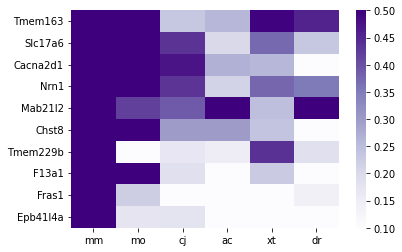

In [195]:
ax = sns.heatmap(df_corr_order, cmap = 'Purples', vmax = .5, vmin = 0.1)
ax.set_facecolor('grey')
plt.savefig('Figures/Figures_07072026/3F_Uncx_Lhx5_downstream_scenic_noTF_07072026.svg')
plt.savefig('Figures/Figures_07072026/3F_Uncx_Lhx5_downstream_scenic_noTF_07072026.pdf')

In [196]:
df_corr_order

,mm,mo,cj,ac,xt,dr
Tmem163,0.627518,0.582247,0.234360,0.258291,0.496429,0.454606
Slc17a6,0.635515,0.657816,0.435644,0.201949,0.372859,0.234216
Cacna2d1,0.588608,0.618140,0.473486,0.267412,0.257940,-0.090343
Nrn1,0.769599,0.686758,0.434141,0.211202,0.375231,0.352948
Mab21l2,0.601096,0.420247,0.390263,0.508492,0.245637,0.810203
Chst8,0.631208,0.524149,0.299215,0.298908,0.238649,0.063675
Tmem229b,0.594805,0.017564,0.167725,0.153763,0.438652,0.183815
F13a1,0.585752,0.687344,0.184846,0.016382,0.227017,0.004041
Fras1,0.658083,0.222173,0.025516,0.067585,0.088980,0.141887
Epb41l4a,0.602392,0.173978,0.176138,0.097063,0.014636,-0.004744


In [197]:
df_corr_order.to_csv('Figures/Figures_07072026/3F_Uncx_Lhx5_downstream_scenic_noTF_07072026.csv')

In [ ]:
#checking regulation

In [152]:
df_corr_order = pd.read_csv('Figures/Figures_07072026/3F_Dlx_Isl1_downstream_scenic_noTF_07072026.csv',index_col = 'Unnamed: 0')

In [154]:
df_corr_order.index

Index(['Slc32a1', 'Gad1', 'Gad2', 'Grik3', 'Nrxn3', 'Ecel1', 'Actr5', 'Cpne2',
       'Gpc4', 'Eif1b'],
      dtype='object')

In [103]:
g_mapping = pd.DataFrame(data = [dlx_list,
                     [mo_exp[i] for i in dlx_list],
                     [cj_exp[i] for i in dlx_list],
                     [ac_exp[i] for i in dlx_list],
                     [xt_exp[i] for i in dlx_list],
                     [dr_exp[i] for i in dlx_list]],
             index = ['Mouse name','Vole name','Quail name','Anole name','Xenopus name','Zebrafish name']).T

In [104]:
g_mapping

,Mouse name,Vole name,Quail name,Anole name,Xenopus name,Zebrafish name
0,Slc32a1,Slc32a1,SLC32A1,slc32a1,slc32a1,slc32a1
1,Gad1,Gad1,GAD1,gad1,gad1.1,gad1b
2,Gad2,Gad2,GAD2,gad2,gad2,gad2
3,Grik3,Grik3,GRIK3,grik3,grik3,grik3
4,Nrxn3,Nrxn3,NRXN3,nrxn3,nrxn3,nrxn3a
5,Ecel1,Ecel1,ECEL1,ecel1,ecel1,ecel1
6,Actr5,Actr5,ACTR5,actr5,actr5,actr5
7,Abat,Abat,ABAT,abat,NaN,abat
8,Gpc4,Gpc4,GPC4,gpc4,gpc4,gpc4
9,Eif1b,ENSMOCG00000000649,EIF1B,eif1b,eif1b,eif1b


In [240]:
neb = ['Tmem163','Slc17a6','Dpf3','Nrn1','Adora1','Cxxc5','Chst8','Samd3','Cacna2d1','F13a1','Fras1','Mrps15','Epb41l4a','Ly75','Tmem229b']
ntcf = ['St18','Nfia','Nfib','Zfp536','Chd7','Adamtsl3','Mcm6','S100a16','P2rx7','Dennd2a','Rnf141','Htr3a','Fdxr','Gpd1','Tns3']

In [239]:
for item in neb:
    TFs = set(scenic[scenic['Gene'] == item]['TF'])
    print(item)
    if 'Ebf3' in TFs:
        print('Ebf3')
    if 'Uncx' in TFs:
        print('Uncx')

Tmem163
Uncx
Slc17a6
Uncx
Dpf3
Uncx
Nrn1
Uncx
Adora1
Ebf3
Cxxc5
Uncx
Chst8
Uncx
Samd3
Uncx
Cacna2d1
Uncx
F13a1
Uncx
Fras1
Uncx
Mrps15
Uncx
Epb41l4a
Uncx
Ly75
Uncx
Tmem229b
Uncx


In [243]:
for item in ntcf:
    TFs = set(scenic[scenic['Gene'] == item]['TF'])
    print(item)
    if 'Tcf4' in TFs:
        print('Tcf4')
    if 'Nfix' in TFs:
        print('Nfix')
    print('----')

St18
Nfix
----
Nfia
Tcf4
Nfix
----
Nfib
Tcf4
Nfix
----
Zfp536
Nfix
----
Chd7
Tcf4
Nfix
----
Adamtsl3
Tcf4
----
Mcm6
Tcf4
----
S100a16
Nfix
----
P2rx7
Tcf4
----
Dennd2a
Tcf4
Nfix
----
Rnf141
Nfix
----
Htr3a
Nfix
----
Fdxr
Tcf4
Nfix
----
Gpd1
Nfix
----
Tns3
Tcf4
Nfix
----
